# Lab 2: Constrained minimization

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm as cm
import math as mt
from numpy import linalg as ln
import time

# I. Introduction: <a id='I'></a>

In this lab session, we present three different ways to numerically solve a convex, quadratic minimization problem with a single linear equality constraint
$$
\text{minimize } f(x)= \frac{1}{2}x^TAx+b^Tx\text{ over all }x\in \mathbb{R}^N\text{ such that } c(x)=d^Tx-1=0,
$$
with $A$ symmetric positive definite, and $b,d\in \mathbb{R}^N$, with $d\neq 0$. 

**Question 1** Prove that there is a unique minimizer $x^*$. Write down the 1st order necessary condition for minimization.

**Solution 1**

To prove that there exists a unique minimizer $x^*$, we must show that $f(x)$ is coercive and convex and $c(x)$ must be convex too.

* $f$ is coercive since A is a positive definite matrix and the function is quadratic then when $\Vert x \Vert \rightarrow + \infty$, $x^TAx$ is dominant compared with $b^Tx$.

Hence,

$$
\lim_{\Vert x \Vert \rightarrow + \infty} f(x) = \lim_{\Vert x \Vert \rightarrow + \infty} \frac{1}{2}x^TAx = +\infty
$$

* We know that $\nabla f(x) = Ax + b \text{ and } Hf(x) = A$ by the Taylor expansion, and kwowing that A is symmetric positive definite means that f(x) is stricly convex

* $c(x)$ is an affine function $\implies$ $c$ is convex

Finally, we proved that ther exists a unique minimizer $x^*$.

* 1st order necessary condition:

$$\text{if } x^* \text{ is a minimizer , then } \exists\lambda \text{ such that } \nabla f(x^*) + \lambda\nabla c(x^*) = 0$$

with $\nabla c(x) = d$

**Question 2** Deduce that $x^*=-A^{-1}(b+\lambda d)$, with $\displaystyle \lambda=-\frac{1+d^TA^{-1}b}{d^TA^{-1}d}$. 

Write programs with input $x$ that return $f(x)$, gf$=\nabla f(x)$, $c(x)$ and gc$=\nabla c(x)$, and one that returns $x^*$ and the Lagrange multiplier $\lambda$ directly.

**Note:** We will consider the case the case $N=2$ to allow figures, but codes should be written to allow arbitrari matrix sizes. For the tests and figures, use
$$
A=\begin{pmatrix}2&-1\\-1&2\end{pmatrix},\ b=\begin{pmatrix}1\\3\end{pmatrix},\ d=\begin{pmatrix}1\\1\end{pmatrix}.
$$

**Solution 2**

We can conclude that, 

$$
\begin{array}{lcl}
&\nabla f(x^*) + \lambda\nabla c(x^*) = 0 \\
&\iff Ax^*+b  + \lambda d = 0 \\
&\iff Ax^* = -(b + \lambda d) \\
&\iff x^* = -A^{-1}(b + \lambda d) \\
\end{array}
$$

and we apply the constraint,

$$
\begin{array}{lcl}
&d^Tx^* = 1 \\
&\iff -d^TA^{-1}(b + \lambda d) = 1 \\
&\iff -d^TA^{-1}b -d^TA^{-1} \lambda d = 1  \\
&\iff -d^TA^{-1} \lambda d = 1 + d^TA^{-1}b\\
&\iff \lambda = -\frac{1 + d^TA^{-1}b}{d^TA^{-1} d}\\
\end{array}
$$

In [48]:
A=np.array([[2,-1],[-1,2]])
b=np.array([1,3])
d=np.array([1,1])

In [40]:
##Solution 2: fill in the BLANKs
def objective(x):
    return np.sum(x*(0.5*A*x+b))

def gradobj(x):
    return np.sum(A * x + b)

def constraints(x):
    return np.sum(d*x)-1

def gradconstraints(x):
    return d

def OptimSetup(x):
    f=objective(x)
    gf=gradobj(x)
    c=constraints(x)
    gc=gradconstraints(x)
    return (f,gf,c,gc)

def exactmin(A,b,d):
    Amd= np.linalg.solve(A,d)
    lamb=-(1.+np.sum(b*Amd))/np.sum(d*Amd)
    solution=-np.linalg.solve(A,b+lamb*d)
    y= objective(solution)
    cons=constraints(solution)
    return (solution,lamb,y,cons)

**Question 3** Compute $x^*, \lambda$ and $y^*=f(x^*)$ in this case. Then, using code from the previous session, level sets of $f$ around $x^*$ (including that at value $y^*$), and the set defined by the constraints (1-level set of c) have all been drawn. 

Geometrically, what do you notice?

In [49]:
sol,lamb,minf,cons=exactmin(A,b,d)
print(sol,lamb,minf,cons)

[0.83333333 0.16666667] -2.5 3.0277777777777777 0.0


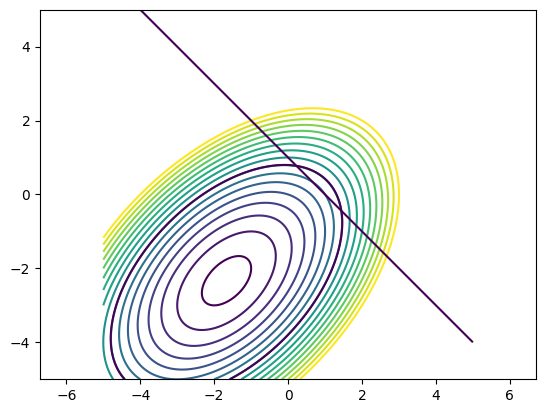

In [50]:
import matplotlib.pyplot as plt 

def level_lines(f, xmin, xmax, ymin, ymax, levels, N=500):
    x = np.linspace(xmin, xmax, N)
    y = np.linspace(ymin, ymax, N)
    z = f(*np.meshgrid(x, y))
    level_l = plt.contour(x, y, z, levels=levels)

f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y
c = lambda x, y: x+y-1

level_lines(f, -5, 5, -5, 5, np.linspace(-4, 12, 17))
level_lines(f, -5, 5, -5, 5, np.linspace(minf, minf, 1))
level_lines(c, -5, 5, -5, 5, np.linspace(0, 0, 1))

plt.axis('equal')
plt.show()

**Solution 3**:

We displayed the constraint and some levels lines of $f$ centered on the unconstrained minimizer. One ellipse touches the constraint line meaning that the touching point is the contraint minimizer.

# I. Penalization: <a id='I'></a>

This method consists in replacing the constrained minimization by an unconstrained, penalized minimization problem as follows:
$$
\text{Minimize } f_\rho(x)=f(x)+\rho \Vert c(x)\Vert^2\text{ over all }x\in \mathbb{R^N}.
$$
Here, we take $\rho$ to be a large positive number. Notice that for linear constraints, $f$ convex implies $f_\rho$ convex.

In our case,
$$
f_\rho(x)=\frac{1}{2}x^TAx+b^Tx+\rho(d^Tx-1)^2.
$$

**Question 4** Show that 
$$
\nabla f_\rho(x)=\nabla f(x)+2\rho c(x)\nabla c(x)=(A+2\rho dd^T)x+b-2\rho d,
$$
and compute the minimizer $x^*_\rho$ of $f_\rho$.

**Solution 4**

$$
\begin{array}{lcl}
&f_\rho(x + h) = \frac{1}{2}(x+h)^TA(x+h) + b^T(x+h) + \rho c(x+h)^Tc(c+h) \\
&= \frac{1}{2}(x^TAx+ 2x^TAh + h^TAh) + b^Tx+ b^Th + \rho (d^Tx + d^Th - 1)^T(d^Tx + d^Th - 1) \\
&= f(x) + (x^TA + b^T)h + \frac{1}{2}h^TAh + \rho (x^Tdd^Tx + x^Tdd^Th - x^Td + h^Tdd^Tx + h^Tdd^Th - h^Td - d^Tx - d^Th + 1) \\ 
&= f(x) + \nabla f(x)^T + \frac{1}{2}h^TAh + \rho \lVert c(x) \rVert^2 + 2\rho(x^Tdd^T - d^T)h + \frac{1}{2}h^T2dd^Th
\end{array}
$$

This implies :

$$
\begin{array}{lcl}
&\nabla f_\rho(x) = \nabla f(x) + 2\rho(x^Tdd^T - d^T)^T \\
&= \nabla f(x) + 2\rho(x^Td - 1)^Td^T \\
&= \nabla f(x) + 2\rho c(x)\nabla c(x) \\
&= Ax + b + 2 \rho d(d^Tx -1) \\
&= (A + 2\rho dd^T)x + b - 2\rho d
\end{array}
$$

To find the minimizer $x^*$, we compute:

$$
\begin{array}{lcl}
&\nabla f(x^*) = 0\\
&\iff  (A + 2\rho dd^T)x^* + b - 2\rho d = 0\\
&\iff (A + 2\rho dd^T)x^* = 2\rho d - b \\
&\iff x^* = (A + 2\rho dd^T)^{-1} (2\rho d - b)
\end{array}
$$

**Question 5** Code functions that compute, for any given $x$, the values of $f(x)$, $\nabla f_\rho(x)$ and $x_\rho^*$. Verify numerically that $x_\rho^*\rightarrow x^*$ as $\rho$ goes to infinity.

In [43]:
#Solution 5
#Tip :  dd^T can be coded as        np.matmul(d[:,np.newaxis],d[np.newaxis,:])
rho=10

def objpen(x):
    return objective(x)+rho*(constraints(x)**2)

def gradobjpen(x):
    return gradobj(x)+2*rho*constraints(x)*gradconstraints(x)

def minpen(A,b,d,rho):
    
    xrho = np.linalg.inv(A+2*rho*np.matmul(d[:,np.newaxis],d[np.newaxis,:])) @ (2*rho*d - b)
    return xrho

In [44]:
##verify that as rho goes to infinity, xrho goes to the solution
rho=100
xrho=minpen(A,b,d,rho)
print(xrho,sol)

[0.82709892 0.16043225] [0.83333333 0.16666667]


**Question 5** Write a code that uses gradient descent with a basic linesearch to minimize $f_\rho$ in 1000 steps (forego the usual stopping criterion). 

Test it for $\rho=1,10,100,1000$, drawing the trajectory of the sequence over the level sets of $f$.

In [45]:
## Solution 5: Fill in the BLANKS
def optim(f, gradf, beta, gamma, x0, N): # beta and gamma are the linesearch parameters
    xi = x0
    X=[np.copy(x0)]
    for i in range(N):
        alpha = 1
        d = - gradf(xi)
        j=0
        while f(xi + alpha * d) > f(xi) + gamma * alpha * np.dot(d, gradf(xi)) and j<20: #linesearch
            j=j+1
            alpha = beta * alpha
        xi = xi + alpha * d
        X.append(np.copy(xi))
    return np.array(X)

C:\Users\maner\AppData\Local\Temp\ipykernel_8748\1225534847.py:6: RuntimeWarning: overflow encountered in scalar multiply
  return objective(x)+rho*(constraints(x)**2)
C:\Users\maner\AppData\Local\Temp\ipykernel_8748\1225534847.py:6: RuntimeWarning: overflow encountered in scalar power
  return objective(x)+rho*(constraints(x)**2)
C:\Users\maner\AppData\Local\Temp\ipykernel_8748\1819300648.py:3: RuntimeWarning: overflow encountered in multiply
  return np.sum(x*(0.5*A*x+b))
C:\Users\maner\AppData\Local\Temp\ipykernel_8748\3380725156.py:9: RuntimeWarning: overflow encountered in dot
  while f(xi + alpha * d) > f(xi) + gamma * alpha * np.dot(d, gradf(xi)) and j<20: #linesearch
C:\Users\maner\AppData\Local\Temp\ipykernel_8748\1225534847.py:9: RuntimeWarning: overflow encountered in scalar multiply
  return gradobj(x)+2*rho*constraints(x)*gradconstraints(x)


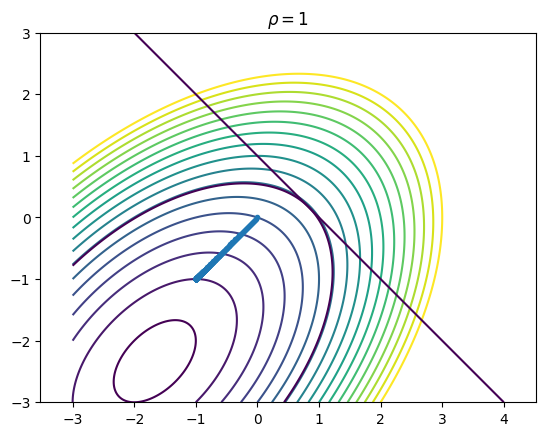

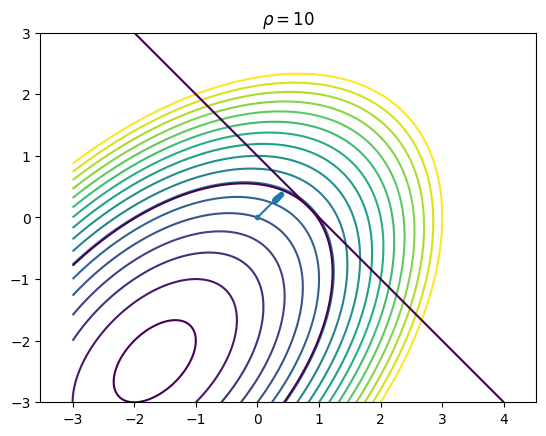

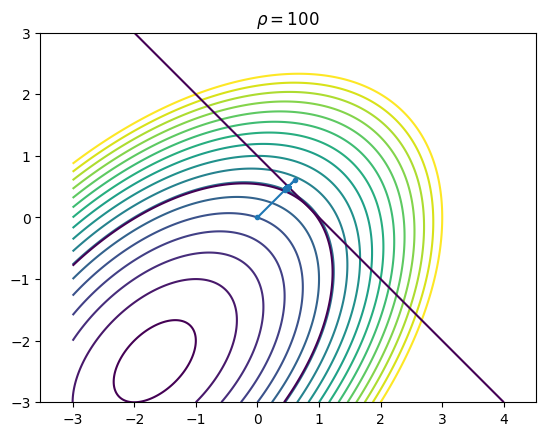

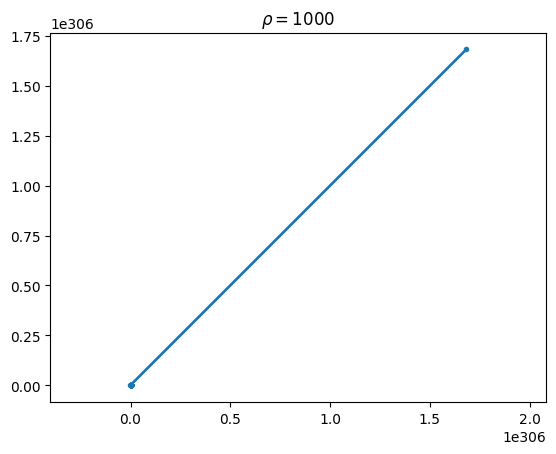

In [80]:
x0=np.array([0,0])
beta=0.75
gamma=0.5
N=1000

##plotting results for rho=1,10...
for i in range(4):
    rho=10**i
    Xrho=optim(objpen, gradobjpen, beta, gamma, x0, N)
    plt.figure()
    plt.title(fr"$\rho=${rho}")
    f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y
    c = lambda x, y: x+y-1
    level_lines(f, -3, 3, -3, 3, np.linspace(-4, 12, 17))
    level_lines(f, -3, 3, -3, 3, np.linspace(1.9166666666666667, 1.9166666666666667, 1))
    level_lines(c, -3, 4, -3, 3, np.linspace(0, 0, 1))
    plt.plot(Xrho[:,0],Xrho[:,1],'.',linestyle='-')
    plt.axis('equal')

**Question 6** Draw the level sets of $f_\rho$ for $\rho=1,10,100$. Comment.

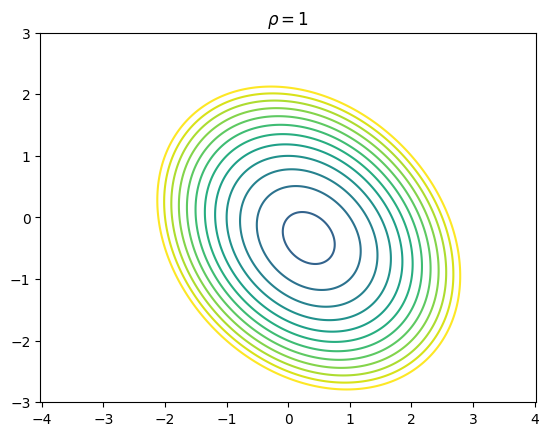

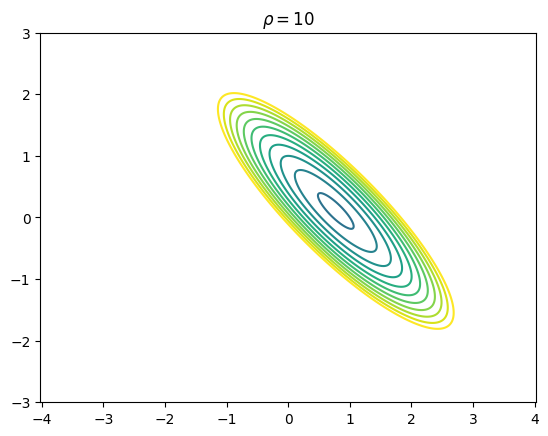

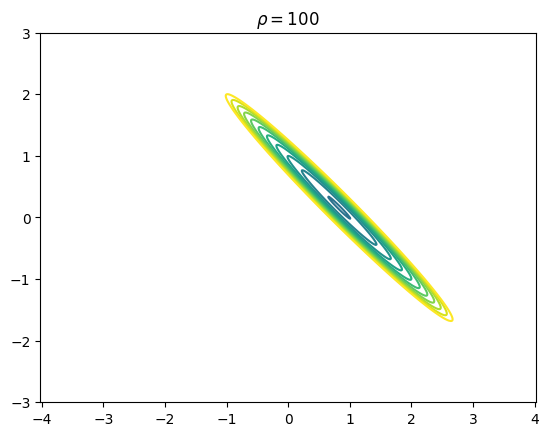

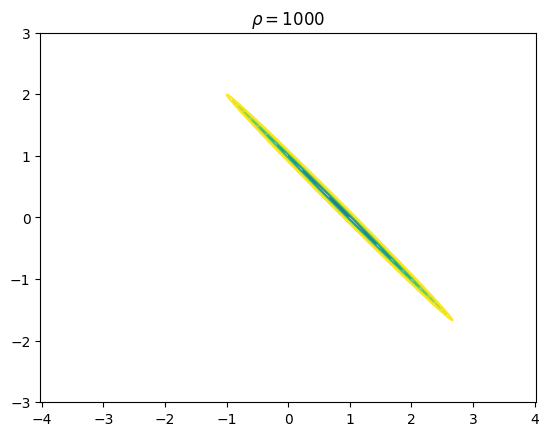

In [47]:
##Solution 6
for i in range(4):
    plt.figure()
    rho=10**i
    f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y+rho*(x+y-1)**2
    level_lines(f, -3, 3, -3, 3, np.linspace(-4, 12, 17))
    plt.axis('equal')
    plt.title(fr"$\rho=${rho}")
    plt.show()
    time.sleep(0.1)

**Solution 6**

When $\rho$ grows too much, the ellipses are squeezing strongly, meaning that we will get huge gradients which explain that the model diverges at some point when $\rho$ is too big

# II. Projected Gradient: <a id='I'></a>

**Question 7 (Bonus)** Let $C$ be a convex set subset of $\mathbb{R}^N$. Prove that for any $x\in\mathbb{R}^N$, there is a unique point $P_C(x)\in C$ such that for any $y\in C$, $\Vert x -P_C(x)\Vert\leq \Vert x-y\Vert$. In other words, $P_C(x)$ is the projection of $x$ onto $C$. 

When $C$ is an affine subspace, $P_C(x)$ is just the orthogonal projection onto $C$.

**Solution 7**

The Projected Gradient method consists in starting from a point $x_0$ in the constrained set $C$ and, at each step, applying the unconstrained gradient descent, followed by the projection of the descended point obtained back to the constrained set. So, for $k=0,1,2,\ldots\ $ up to convergence, repeat:

$$
\left|
\begin{array}{lcl}
v^k& \longleftarrow & -\nabla f(x^k),\\
\alpha^k &\longleftarrow &\text{Line-search}\ \left(\ t\mapsto f(P_c(x^k + tv^k))\ \right),\\ 
x^{k+1}&\longleftarrow &P_c(x^k+\alpha^k v^k)
\end{array}
\right.
$$
where $P_C$ is the projection operator onto the set of constraints $C=\{x,\ c(x)=0\}$ defined in Question 7. 

In this case, the linesearch step needs to be adjusted: instead of asking for 
$$
f(x^k + tv^k)<f(x^k)-t\gamma \nabla f(x^k)^Tv^k,
$$ 
we replace $v^k$ with $P(x^k+tv^k)-x^k$, so the condition becomes  
$$
f(P_C(x^k + tv^k))<f(x^k)-t\gamma \nabla f(x^k)^T(P_C(x^k+tv^k)-x^k)).
$$

**Example**: For a constraint like $C=\{(0,x_2)\in \mathbb{R}^2\}$, $P_C(x_1,x_2)=(0,x_2)$, so the algorithm becomes

$$
\left|
\begin{array}{lcl}
v^k=\begin{pmatrix}v^k_1\\v^k_2\end{pmatrix}& \longleftarrow & -\nabla f(x^k),\\
\alpha^k &\longleftarrow &\text{Line-search}\ \left(\ t\mapsto f(P_c(x^k + tv^k))=\ f\begin{pmatrix}0\\x^k_2+tv^k_2\end{pmatrix}\right),\\ 
x^{k+1}&\longleftarrow &\begin{pmatrix}0\\x^k_2+\alpha^kv^k_2\end{pmatrix}
\end{array}
\right.
$$

**Question 8** In our case, prove that $\displaystyle P_C(x)=x-\frac{d^Tx-1}{\Vert d\Vert^2}d$. 

Code the projection function $P_C(x)$ and test it on some points.

**Solution 8** 

$P_C(c)$ is the unique point $y \in C$ such that ${\Vert x-y \Vert^2}$ is minimized

$C$ is an affine subspace then we can write it as 
$$
C = x_0 + \ker(d^T) \text{ where $x_0$ is a particular point in $C$ sucht that } d^Tx_0=1
$$

Also, $\ker(d^T) = \{h \in \mathbb{R}^N, d^Th = 0\}$

To have $y = P_C(x)$, we must verify 2 conditions:
* $y \in C$, i.e $d^Ty = 1$
* $x-y$ must be orthogonal to the hyperplane, hence colinear with $d$

Then it exists a $k$ such that:
$$
x-y = kd \iff y = x - kd
$$

Let's compute $k$:
$$
d^Ty = 1 \iff d^T(x-kd) = 1 \iff d^Tx - kd^Td = 1 \iff k\Vert d \Vert^2 = d^Tx -1 \iff k = \frac{d^Tx-1}{\Vert d \Vert^2}
$$

We can conclude by replacing $k$ in $y=x-kd$

$$
P_C(x) = x - \frac{d^Tx-1}{\Vert d \Vert^2}d
$$

In [51]:
#Solution 8 fill in the BLANK
def proj(x):
    return x- (d.T@x -1)/(d.T@d)*d

In [52]:
x0=np.array([0,0]) 
x1=np.array([1,2])
x2=np.array([0.5,0.5])
y0=proj(x0)
y1=proj(x1)
y2=proj(x2)
print(y0, y1, y2)
print(constraints(y0),constraints(y1),constraints(y2))

[0.5 0.5] [0. 1.] [0.5 0.5]
0.0 0.0 0.0


**Question 9** Write the projected gradient algorithm and test it for $N=10$ steps. Draw the sequence $(x_0,x_1,...)$ on a figure along with level sets of $f$ and the constraints set. 

In [53]:
#Solution 9
#tip: don't forget to ensure x0 belong to C (p is the projection function )
#
def optimproj(f, gradf, p, beta, gamma, x0, N, niter_ls_max): # beta and gamma are the linesearch parameters
    X=[np.copy(x0)]
    xi = p(x0)
    X.append(np.copy(xi))
    for i in range(N):
        alpha = 1
        d = -gradf(xi)
        j=0
        xtest = p(xi + alpha*d)
        while j<20 and f(xtest) > f(xi) + gamma * alpha * np.sum((xtest - xi) * gradf(xi)):
            j=j+1
            alpha = beta * alpha
            xtest= p(xi + alpha*d)
        xi = xtest
        X.append(np.copy(xi))
    return np.array(X)


(np.float64(-3.0), np.float64(4.0), np.float64(-3.0), np.float64(3.0))

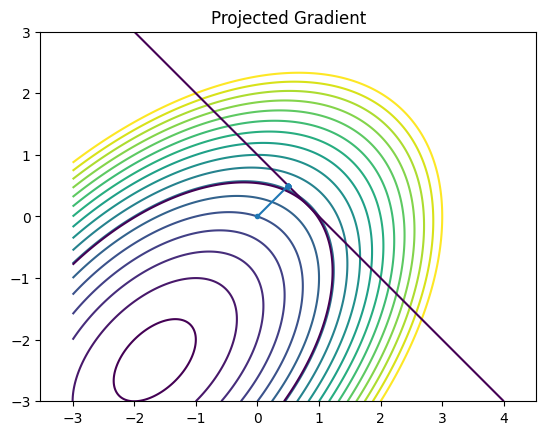

In [54]:
x0=np.array([0,0])
beta=0.75
gamma=0.5
N=10
niter_ls_max=20
X=optimproj(objective, gradobj, proj, beta, gamma, x0, N, niter_ls_max)
plt.figure()
plt.title(fr"Projected Gradient")
f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y
c = lambda x, y: x+y-1
level_lines(f, -3, 3, -3, 3, np.linspace(-4, 12, 17))
level_lines(f, -3, 3, -3, 3, np.linspace(1.9166666666666667, 1.9166666666666667, 1))
level_lines(c, -3, 4, -3, 3, np.linspace(0, 0, 1))
plt.plot(X[:,0],X[:,1],'.',linestyle='-')
plt.axis('equal')

**Question 10** Can you think of circumstances where this method could be too computationnally intensive to be useful?

**Solution 10**

This method could be too computationnally intensive if we have a high dimensional problems or if the projection is costly to compute.

# III. Duality-based Lagrangian method: Uzawa update <a id='I'></a>

This method is based on a result from class (to be seen next time). Define the Lagrangian
$$
\mathcal{L}(x,\lambda)=f(x)+\lambda c(x),\ x\in \mathbb{R}^N,\ \lambda\in \mathbb{R}.
$$
Note that for $x\in C=\{x,\ c(x)=0\}$, $\mathcal{L}(x,\lambda)=f(x)$ for every $\lambda$.

**Question 11** Let $(x^*,\lambda^*)\in \mathbb{R}^N\times\mathbb{R}$ be the constrained minimizer and corresponding lagrange mutliplier:
$$
\nabla f(x^*)+\lambda^*\nabla c(x^*)=0.
$$
Prove that $\nabla\mathcal{L}(x^*,\lambda^*)=0$.

**Solution 11** 

Let $(x^*,\lambda^*)\in \mathbb{R}^N\times\mathbb{R}$ the constrained minimizer and corresponding lagrange mutliplier

**Theorem:** For a convex functions and affine constraints,
$$
f(x^*)=\max_{\lambda\in \mathbb{R}}\min_{x\in \mathbb{R}^N} \mathcal{L}(x,\lambda)=\mathcal{L}(x^*,\lambda^*).
$$

This leads to an alternating method in which, at each step, we descend in $x$ then ascend in $\lambda$: start with initial guesses $(x_0,\lambda_0)$ for the Lagrange multiplier, then for $k=0,1,2,\dots$, define

$$
\left|
\begin{array}{lcl}
v^k& \longleftarrow & -\nabla_x \mathcal{L}(x^k,\lambda^k),\\
\mu^k& \longleftarrow& \ \nabla_\lambda\mathcal{L}(x^k,\lambda^k),\\
\alpha^k &\longleftarrow &\text{Line-search}\ \left(\ t\mapsto \mathcal{L}(x^k + tv^k,\lambda^k)\ \right),\\ 
x^{k+1}&\longleftarrow &x^k+\alpha^k v^k,\\
\lambda^{k+1}&\longleftarrow &\lambda^k+s^0\mu^k
\end{array}
\right.
$$

**Remark:** $\nabla_\lambda\mathcal{L}(x,\lambda)=c(x).$

**Question 12** For fixed $x$, what is the nature of $\lambda\mapsto \mathcal{L}(x,\lambda)$. Deduce that we can't perform a line-search for the step length of the update of the Lagrange multiplier.µ

**Solution 12**

For fixed $x$, $f(x)$ is then constant meaning that $\lambda\mapsto \mathcal{L}(x,\lambda)$ is an affine function of $\lambda$

The linesearch tries to find minimize $\alpha^k$, however as \mathcal{L}(x,\lambda) is an affine function there no minimizer or maximizer when $\lambda$ goes to $+\infty$ or $-\infty$. We can conclude that there is no best $\alpha$.

**Question 13** Write a code that performs this algorithm for a given number $N$ of steps and $s_0$. Let it run on our problem for $N=100$ and $s=0.1$, $x_0=0$ and $\lambda_0=0$. Draw the result on a figure that includes level sets of $f$ and the constraints. 

In [73]:
##Solution 13
def lagrangian(x,lam):
    return objective(x) + lam*constraints(x)

def gradlagx(x,lam):
    return gradobj(x) + lam*gradconstraints(x)

def gradlaglam(x,lam):
    return constraints(x)

def optimlag(lag,gradx,gradlam,beta,gamma,x0,lam0,s0, N):
    xi = x0
    X=[x0]
    lami=lam0
    for i in range(N):
        alpha = 1
        d = -gradx(xi, lami)
        mu= gradlam(xi, lami)
        xtest=xi + alpha*d
        j=0
        while lag(xtest,lami) > lag(xi,lami) + gamma * alpha * np.sum((xtest-xi)* gradlagx(xi,lami)) and j<20:
            alpha = beta * alpha
            xtest=xi + alpha*d
            j+=1
        xi = xtest
        lami = lami + s0 * mu
        X.append(xi)
    lamn=lami
    return (np.array(X),lamn)
    


(np.float64(-4.2031640625),
 np.float64(3.0),
 np.float64(-4.2031640625),
 np.float64(3.0))

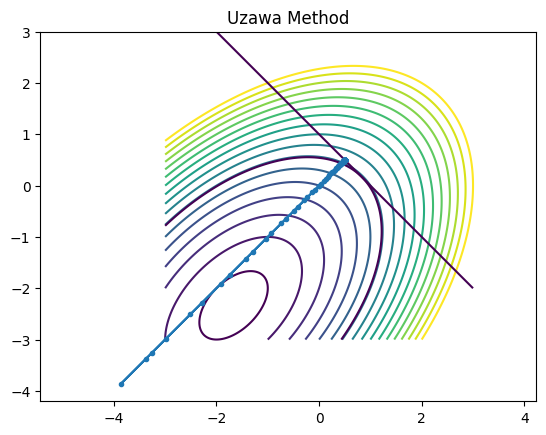

In [74]:
beta=0.75
alpha=0.5
lam0=0
x0=np.array([0,0])
s0=0.1
N=100
X,lam = optimlag(lagrangian,gradlagx,gradlaglam,beta,gamma,x0,lam0,s0, N)
plt.figure()
plt.title(fr"Uzawa Method")
f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y
c = lambda x, y: x+y-1
level_lines(f, -3, 3, -3, 3, np.linspace(-4, 12, 17))
level_lines(f, -3, 3, -3, 3, np.linspace(1.9166666666666667, 1.9166666666666667, 1))
level_lines(c, -3, 3, -3, 3, np.linspace(0, 0, 1))
plt.plot(X[:,0],X[:,1],'.',linestyle='-')
plt.axis('equal')

In [ ]:
print(X[-1],lam)
print(sol,lam)

**Question 15** Try the algorithm with $s=1$ and $s_0=0.001$. Discuss.

(np.float64(-13.0), np.float64(8.0), np.float64(-13.0), np.float64(3.0))

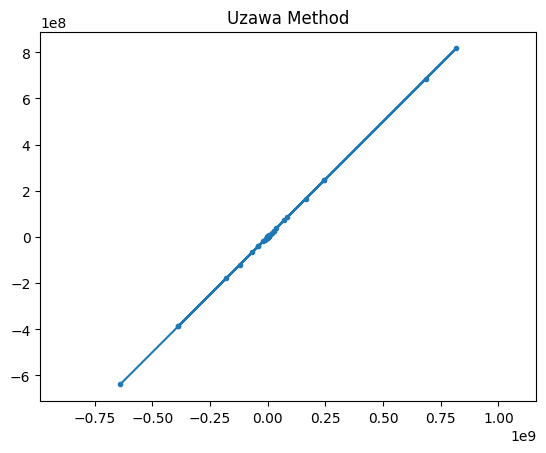

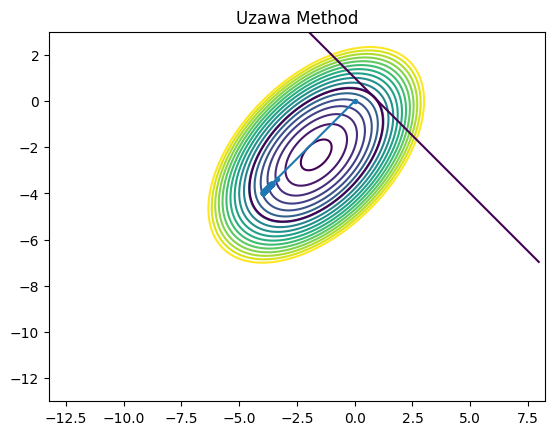

In [78]:
lam0=0
x0=np.array([0,0])
s0=1
N=100
X,lam = optimlag(lagrangian,gradlagx,gradlaglam,beta,gamma,x0,lam0,s0, N)
plt.figure()
plt.title(fr"Uzawa Method")
f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y
c = lambda x, y: x+y-1
level_lines(f, -13, 3, -13, 3, np.linspace(-4, 12, 17))
level_lines(f, -13, 3, -13, 3, np.linspace(1.9166666666666667, 1.9166666666666667, 1))
level_lines(c, -13, 8, -13, 3, np.linspace(0, 0, 1))
plt.plot(X[:,0],X[:,1],'.',linestyle='-')
plt.axis('equal')

s0=0.001
N=100
X,lam = optimlag(lagrangian,gradlagx,gradlaglam,beta,gamma,x0,lam0,s0, N)
plt.figure()
plt.title(fr"Uzawa Method")
f = lambda x, y: 0.5*(2*x**2-2*x*y+2*y**2)+x+3*y
c = lambda x, y: x+y-1
level_lines(f, -13, 3, -13, 3, np.linspace(-4, 12, 17))
level_lines(f, -13, 3, -13, 3, np.linspace(1.9166666666666667, 1.9166666666666667, 1))
level_lines(c, -13, 8, -13, 3, np.linspace(0, 0, 1))
plt.plot(X[:,0],X[:,1],'.',linestyle='-')
plt.axis('equal')

**Solution 15**

With $s_0 = 1$ the methods diverges since lambda will change too fast. With $s_0 = 0.001$ it converges slowly then choosing a right $s_0$ is important to get the minimizer.

**Question 16** Discuss each method's pros and cons, and which do you believe to be the best, both in general and for this specific minimization problem.

**Solution 16**

* KKT :
   * pros: Numerically stable for small problems, no need to choose hyperparameter, fast
   * cons: not able to compute non linear system, sensitive to high dimension
* Penalization :
   * pros: Transforms constrained into unconstrained problems and simple to implement.
   * cons: Diverges if $\rho$ too large, can be slow and numerically unstable
* Uzawa :
   * pros: Scales to large problems
   * cons: sensitive to the choice of $s_0$, slower convergence than the other.

The best choice in our case,  is still the KKT since we are in low dimension then the gradient descent converges well too the right minimizer.

In general, the best will always be the Uzawa methods since it fits well with large-scale constrained problems.